# ЛАБОРАТОРНА РОБОТА 4

In [ ]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans

### 1. Завантаження зображення

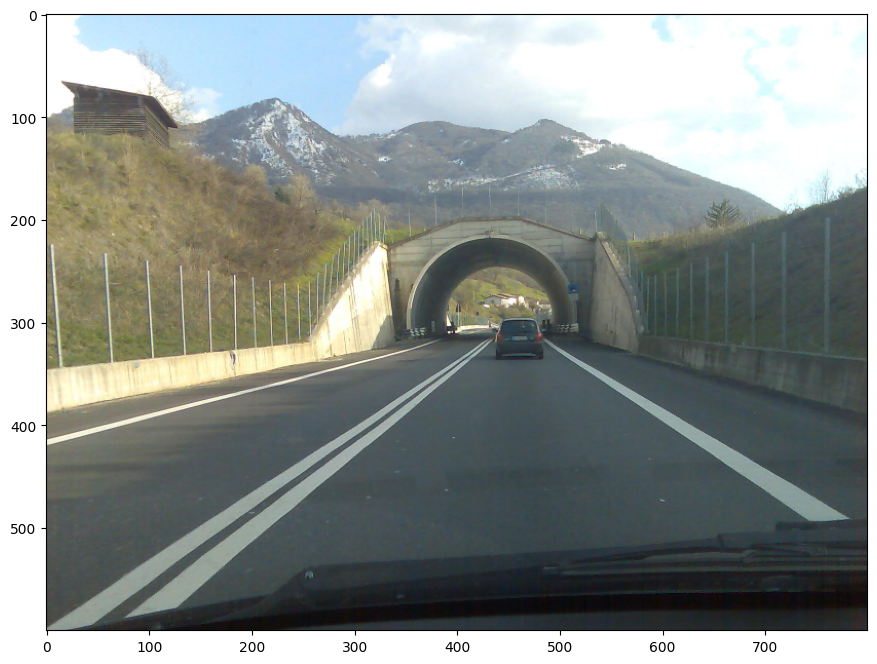

In [237]:
img = cv2.imread('dashcam.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, None, fx=0.5, fy=0.5)

plt.imshow(img)

### 2. Перетворення зображення у відтінки сірого та отримання контурів

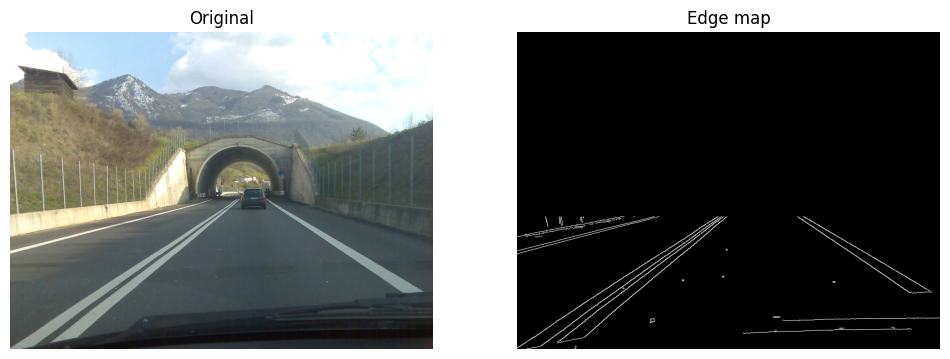

In [238]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

edges = cv2.Canny(gray, 50, 150)
edges[0:350] = 0

plt.figure(figsize=(12, 5))

plt.subplot(121)
plt.imshow(img)
plt.title('Original')
plt.axis('off')

plt.subplot(122)
plt.imshow(edges, cmap='gray')
plt.title('Edge map')
plt.axis('off')

plt.show()

### 3. Застосування перетворення Хафа для параметризації прямих
- rho - роздільна здатність для зміщення
- theta - крок для куту нахилу
- threshold - поріг акумулятора

In [239]:
lines = cv2.HoughLines(
    edges,
    rho = 2,
    theta = np.deg2rad(2),
    threshold = 190
)
print(lines)

[[[521.           0.87266463]]

 [[505.           0.94247776]]

 [[509.           0.9075712 ]]

 [[495.           0.9773844 ]]

 [[ -7.           2.1642082 ]]

 [[401.           1.3264502 ]]

 [[513.           0.94247776]]

 [[583.           1.5358897 ]]

 [[499.           1.012291  ]]

 [[ 31.           2.0943952 ]]

 [[511.           0.9773844 ]]]


In [240]:
lines = lines[:, 0, :]
print(lines)

[[521.           0.87266463]
 [505.           0.94247776]
 [509.           0.9075712 ]
 [495.           0.9773844 ]
 [ -7.           2.1642082 ]
 [401.           1.3264502 ]
 [513.           0.94247776]
 [583.           1.5358897 ]
 [499.           1.012291  ]
 [ 31.           2.0943952 ]
 [511.           0.9773844 ]]


### 4. Відображення прямх на зображенні

In [241]:
def hough_lines(img, lines):
       
    result = np.copy(img)

    for line in lines:
       rho = line[0]
       theta = line[1]

       a = math.cos(theta)
       b = math.sin(theta)

       x0 = a * rho
       y0 = b * rho

       pt1 = (int(x0 + 1000 * (-b)), 
               int(y0 + 1000 * (a)))

       pt2 = (int(x0 - 1000 * (-b)), 
               int(y0 - 1000 * (a)))

       cv2.line(result, pt1, pt2, 255, 1, cv2.LINE_AA)

    return result

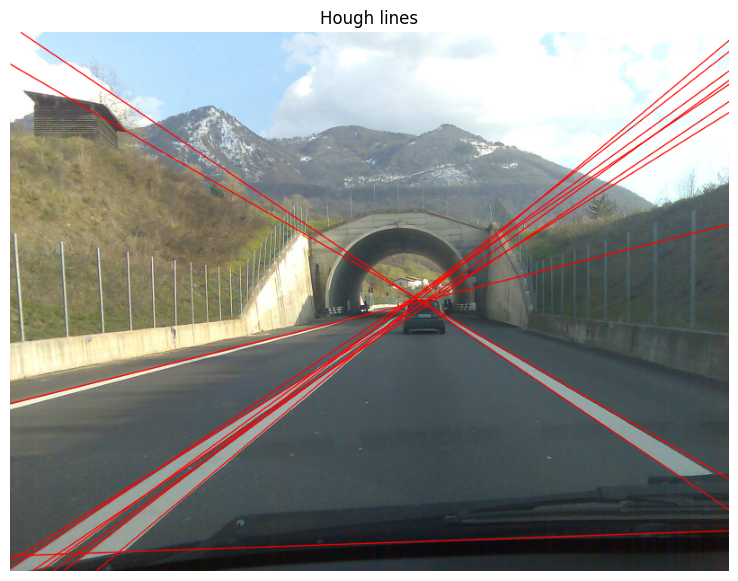

In [242]:
result1 = hough_lines(img, lines)
    
plt.figure(figsize=(10, 7))
plt.imshow(result1)
plt.title('Hough lines')
plt.axis('off')
plt.show()

### 5. Прибираємо всі лінії, які є приблизно горизонтальними

In [243]:
filtered_lines = []

for line in lines:
   
    theta = line[1]
    
    if not (np.deg2rad(80) <= theta <= np.deg2rad(100)):
        filtered_lines.append(line)

filtered_lines = np.array(filtered_lines)

print(filtered_lines)

[[521.           0.87266463]
 [505.           0.94247776]
 [509.           0.9075712 ]
 [495.           0.9773844 ]
 [ -7.           2.1642082 ]
 [401.           1.3264502 ]
 [513.           0.94247776]
 [499.           1.012291  ]
 [ 31.           2.0943952 ]
 [511.           0.9773844 ]]


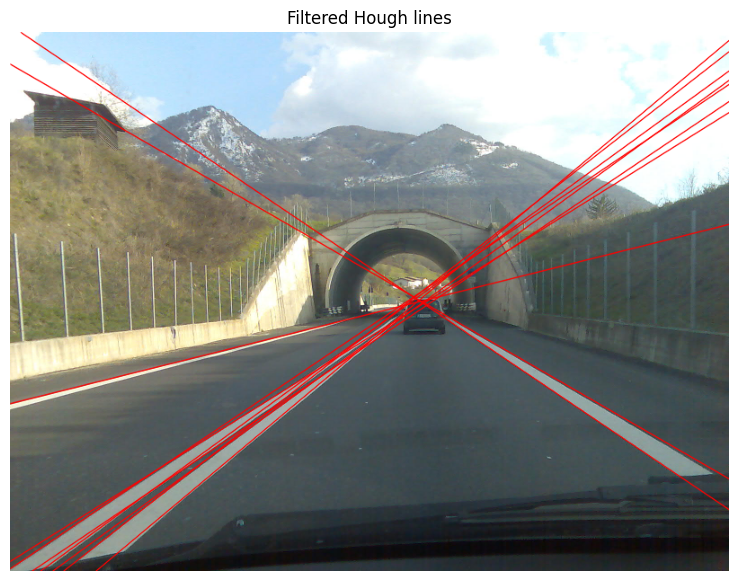

In [244]:
result2 = hough_lines(img, filtered_lines)

plt.figure(figsize=(10, 7))
plt.imshow(result2)
plt.title('Filtered Hough lines')
plt.axis('off')
plt.show()

### 6. Застосування кластеризації

In [245]:
kmeans = KMeans( n_clusters = 6, random_state=42, n_init=10 ).fit(filtered_lines)

print(kmeans.cluster_centers_)

[[497.           0.99483764]
 [ 31.           2.0943952 ]
 [ -7.           2.1642082 ]
 [401.           1.3264502 ]
 [509.5          0.94247776]
 [521.           0.87266463]]


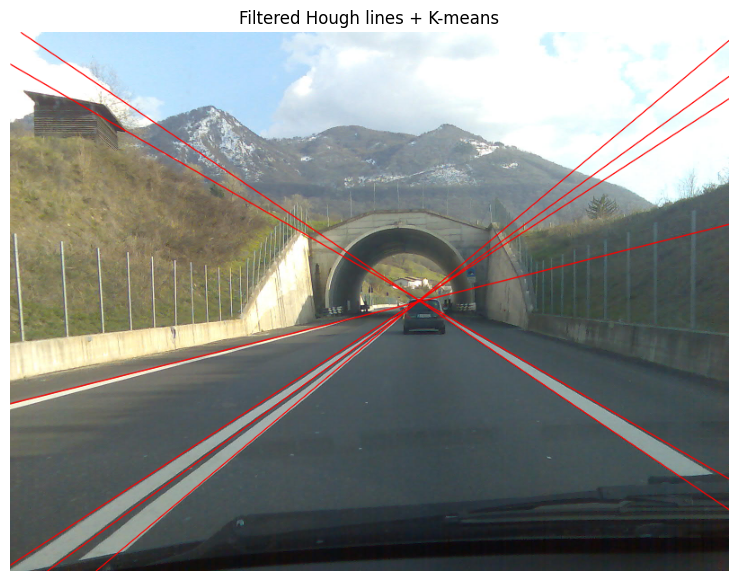

In [246]:
result3 = hough_lines(img, kmeans.cluster_centers_)

plt.figure(figsize=(10, 7))
plt.imshow(result3)
plt.title('Filtered Hough lines + K-means')
plt.axis('off')
plt.show()